## Исследование датасета для проекта «Ценообразование жилой недвижимости с использованием методов машинного обучения на данных ЦИАН»

### 0. Описание данных

* **Количественные признаки:**
  - *price* (целевая переменная) — цена объекта
  - *total_area* – общая площадь
  - *living_area* – жилая площадь
  - *kitchen_area* – площадь кухни
  - *ceiling_height* – высота потолков
  - *floor* – этаж
  - *total_floors* – общее количество этажей
  - *combined_bathroom* – кол-во совмещенных санузлов
  - *separated_bathroom* – кол-во раздельных санузлов
  - *balcony* – кол-во балконов
  - *loggia* – кол-во лоджий
  - *year_of_construction* – год постройки `только для вторичек`
  - *passenger_elevator* – кол-во пассажирских лифтов
  - *cargo_elevator* – кол-во грузовых лифтов
  - *entrances* – количество подъездов `только для вторичек`

* **Категориальные признаки:**
  - *house_type* — тип дома (Блочный/Деревянный/Кирпичный/Монолитно-кирпичный/Монолитный/Панельный/Сталинский/NaN)
  - *view_from_the_windows* — вид из окна (Во двор/На улицу/На улицу и двор/NaN)
  - *repair* — ремонт (Без ремонта/Дизайнерский/Евроремонт/Косметический/NaN) `только для вторичек`
  - *heating* — отопление (Автономная котельная/Индивидуальный тепловой пункт/(Котел/Квартирное отопление)/Нет/Нет информации/Центральное/Электрическое/NaN) `только для вторичек`
  - *parking* — парковка (Многоуровневая/На крыше/Наземная/Открытая/Подземная/NaN)
  - *gas_supply* — газоснабжение (Автономное/Центральное/NaN) `только для вторичек`
  - *apartment* — Апартаменты/Пентхаус/NaN
  - *floor_type* — тип перекрытий (Деревянные/Железобетонные/Смешанные/NaN) `только для вторичек`
  - *finishing* — тип отделки (Без отделки/Нет информации/Под ключ/Предчистовая/С отделкой/Черновая/Чистовая/Чистовая с мебелью/NaN) `только для новостроек`
  - *rooms_count* — формально числовой, но содержит значения "Студия", "Доля", поэтому пока считаем категориальным.

* **Бинарные признаки:**
  - *auction* — аукцион? (в датасете только "Н")
  - *new_biilding* — тип квартиры (Новостройка/Вторичка)
  - *garbage_chute* — мусоропровод (Д/NaN)
  - *concierge* — консьерж (Д/NaN)
  - *accident_rate* — аварийность (Д/Н/NaN) `только для вторичек`
  - *sold_with_furniture* — продается вместе с мебелью (Д/NaN) `только для вторичек`
  - *minor_owners* — несовершеннолетние собственники (Д/Н/NaN)
  - *maternity_capital* — использовался ли маткапитал при покупке (Д/Н/NaN)
  - *ramp* — пандус (Д/NaN) `только для новостроек`

* **Дата и время:**
  - *publication_date* — дата публикации объявления
  - *request_time* — дата парсинга данных объявления

* **Геоданные:**
  - *lat* — широта
  - *lng* — долгота

* **Текстовые (смешанные) данные:**
  - *url* — url объявления
  - *address* — полный адрес объекта
  - *construction_series* — строительная серия `только для вторичек`
  - *metro_info* — информация о ближайших метро (возможно, имеет смысл вычленить только ближайшее метро и время до него, в списке стоит первым)
  - *highway_info* — информация о ближайших дорогах `только для вторичек`
  - *description* — описание объекта, которое заполняется продавцом
  - *seller* — застройщик `только для новостроек`
  - *photos_url* — 15 ссылок на фотографии из объявлений

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cian_full_data.csv', low_memory=False, encoding='utf-8-sig', sep=';')
                
df.head(5)

,url,address,price,auction,rooms_count,new_building,apartment,total_area,living_area,kitchen_area,...,lat,lng,minor_owners,maternity_capital,publication_date,request_time,photos_url,seller,finishing,ramp
0,https://www.cian.ru/sale/flat/324994191/,"Москва, ЮАО, р-н Даниловский, м. Автозаводская...",5350000,Н,Студия,Вторичка,Апартаменты,16.0,10.0,5.0,...,55.703885,37.652768,Н,Н,2025-12-19 12:29:00,2025-12-20 03:40:29,https://images.cdn-cian.ru/images/kvartira-mos...,NaN,NaN,NaN
1,https://www.cian.ru/sale/flat/320317503/,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",5990000,Н,Студия,Вторичка,Апартаменты,16.0,13.5,NaN,...,55.859322,37.515874,NaN,NaN,2025-12-19 16:25:00,2025-12-20 03:40:32,https://images.cdn-cian.ru/images/kvartira-mos...,NaN,NaN,NaN
2,https://www.cian.ru/sale/flat/322151830/,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",5990000,Н,Студия,Вторичка,Апартаменты,15.2,12.7,NaN,...,55.859322,37.515874,NaN,NaN,2025-12-19 19:55:00,2025-12-20 03:40:38,https://images.cdn-cian.ru/images/kvartira-mos...,NaN,NaN,NaN
3,https://www.cian.ru/sale/flat/323600775/,"Москва, ТАО (Троицкий), пос. Рогово, улица Шко...",5500000,Н,1,Вторичка,NaN,32.6,NaN,7.5,...,55.212647,37.072573,NaN,NaN,2025-12-19 18:22:00,2025-12-20 03:40:41,https://images.cdn-cian.ru/images/2690280423-1...,NaN,NaN,NaN
4,https://www.cian.ru/sale/flat/324712040/,"Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, П...",5600000,Н,Студия,Вторичка,NaN,20.0,12.0,3.0,...,55.704996,37.922335,NaN,NaN,2025-12-18 18:26:00,2025-12-20 03:40:44,https://images.cdn-cian.ru/images/2725644747-1...,NaN,NaN,NaN


### Типы данных

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63365 entries, 0 to 63364
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   url                    63365 non-null  object 
 1   address                63365 non-null  object 
 2   price                  63365 non-null  int64  
 3   auction                63365 non-null  object 
 4   rooms_count            63365 non-null  object 
 5   new_building           63365 non-null  object 
 6   apartment              7367 non-null   object 
 7   total_area             63365 non-null  float64
 8   living_area            47957 non-null  float64
 9   kitchen_area           51724 non-null  float64
 10  ceiling_height         49867 non-null  float64
 11  floor                  63365 non-null  int64  
 12  total_floors           63365 non-null  int64  
 13  combined_bathroom      36205 non-null  float64
 14  separated_bathroom     19966 non-null  float64
 15  ba

# 1. Изучение пропусков

#### Изучим долю пропусков для каждого атрибута
##### Обратим внимание на то, что некоторые столбцы заполнены только для новостроек, а какие-то только для вторичек. Исследуем данные, учитывая этот нюанс

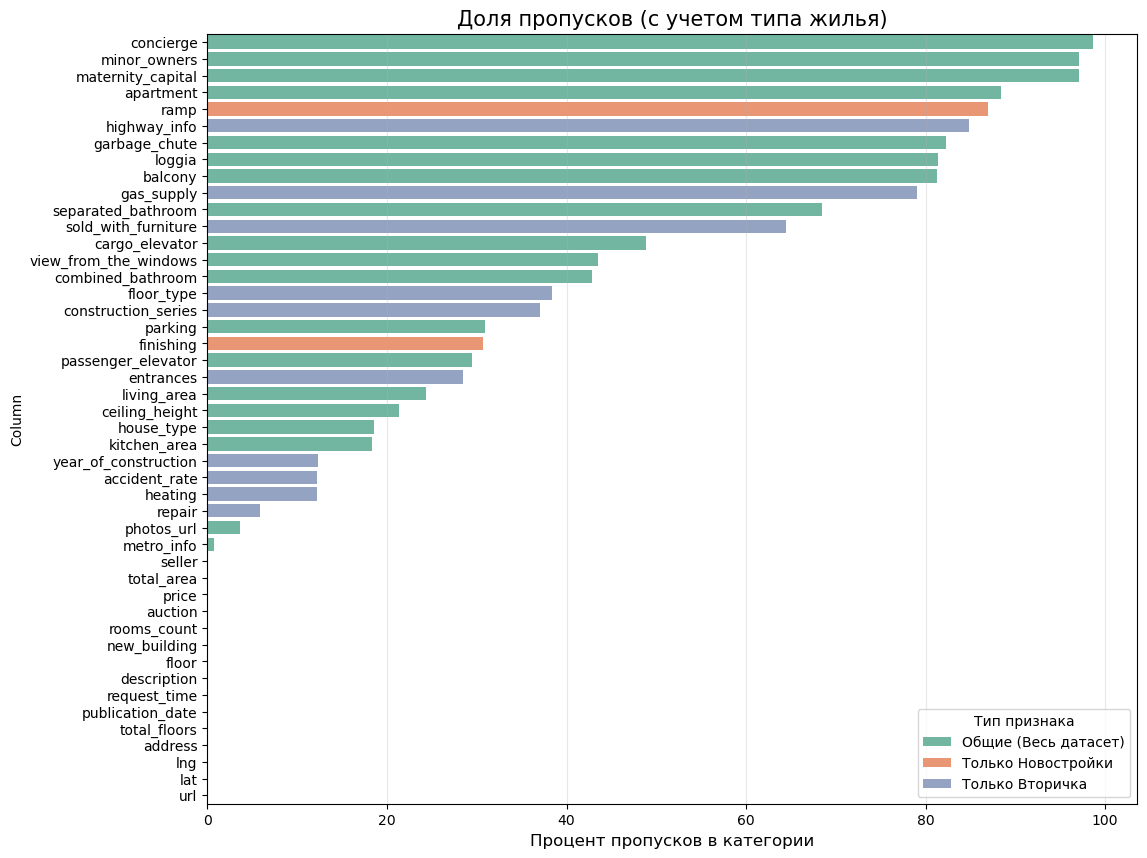

In [58]:
#разделим датасет на два
only_new = df['new_building'] == 'Новостройка'
only_sec = df['new_building'] == 'Вторичка'

#считаем долю пропусков по всему дс
miss_all = df.isna().mean() * 100
#только новостройки
miss_new = df[only_new].isna().mean() * 100
#только вторички
miss_sec = df[only_sec].isna().mean() * 100


#определяем столбцы, которые заполнены только для новостроек
cols_new = miss_sec[miss_sec == 100].index.tolist()

#только во вторичках
cols_sec = miss_new[miss_new == 100].index.tolist()

#ообщие столбцы
cols_common = [c for c in df.columns if c not in cols_new + cols_sec]


#собираем все данные в один датасет с нужной пометкой
plot_data = []

#общие
for col in cols_common:
    plot_data.append({
        'Column': col, 
        'Missing %': miss_all[col], 
        'Group': 'Общие (Весь датасет)'
    })

#вторички
for col in cols_sec:
    plot_data.append({
        'Column': col, 
        'Missing %': miss_sec[col], 
        'Group': 'Только Вторичка'
    })

#новостройки
for col in cols_new:
    plot_data.append({
        'Column': col, 
        'Missing %': miss_new[col], 
        'Group': 'Только Новостройки'
    })

df_plot = pd.DataFrame(plot_data).sort_values('Missing %', ascending=False)


plt.figure(figsize=(12, 10))
sns.barplot(
    data=df_plot, 
    y='Column', 
    x='Missing %',
    hue='Group',
    dodge=False,
    palette='Set2'
)

plt.title('Доля пропусков (с учетом типа жилья)', fontsize=15)
plt.xlabel('Процент пропусков в категории', fontsize=12)
plt.legend(title='Тип признака', loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.show()

#### Некоторые пропуски в данных объясняются тем, что для данного типа жилья в принципе нет такой характеристики (например, отделка во вторичках - все вторички с уже готовым ремонтом), либо данные просто не были заполнены человеком, который выкладывал объявление.
#### На данном этапе пока принято решение никак не обрабатывать пропуски – их всегда можно заменить каким-либо определенным значением, которое будет означать, что информация риелтором не заполнена. Сейчас действуем из предположения, что заполняемость параметров риелтором влияет на конечную стоимость объекта.